# Train COPER end-to-end on per-timestep MDP cluster targets

This notebook **replaces** the mortality objective with prediction of **discrete MDP cluster states** at each hour, using the same join as `copers_to_states.ipynb`:

- **Inputs:** MIMIC tensors from the mortality pickle (`X` shape `(N, T, F)`).
- **Targets:** For each stay, a vector `y \in \{0,\ldots,S-1\}^{L}` with `L=48` blocs, from `per_bloc_state_matrix` on the RL cohort (`cohort_csv_with_mdp_states`).
- **Alignment:** Only stays with **all** blocs `1..L` present in the MDP table are kept (same validity mask as `copers_to_states`).

## What “MDP distribution” means here

The RL pipeline assigns one cluster id per cohort row (KMeans on clinical features). We train with **cross-entropy** on **each** `(stay, t)` pair, i.e. the model outputs logits `(B, L, S)` and we minimize `-\log p(y_{n,t} \mid h_{n,t})`. This is equivalent to matching the **one-hot** distribution over states at each time step.

## Model

We use the same COPER backbone (ODE-in → Perceiver latents → optional second ODE) but **remove** the last-latent + sigmoid head. Instead, a **shared linear** map `W h_{t} + b` is applied at **every** latent slot, producing `S` logits per step — identical readout geometry to the frozen head in `copers_to_states.ipynb`, but **all backbone parameters are trained** on the MDP task.

## Optional warm-start

If `PRETRAINED_STEM` is set to an exported mortality checkpoint stem (e.g. `coper_2node_drop0.5_s1_e3`), backbone weights are loaded with `strict=False` (new `mdp_head` is randomly initialized). Set to `None` to train from scratch.


## Prerequisites

- **Kernel cwd:** the first code cell walks parents from `Path.cwd()` to find the repo root and **prepends it to `sys.path` before** importing `data_mngmt` (works from `notebooks/` or the repo root).
- `paths.json` → mortality pickle with `details['icustay_id']` (unified export).
- `data_mngmt/generated/unified/<slug>/mdp_cohort_<slug>.csv` and MDP metadata (run `build_data` / unified pipeline).
- GPU recommended for full-model training.


In [1]:
from __future__ import annotations

import json
import random
import re
import sys
from pathlib import Path


def _resolve_bench_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "utils" / "load_coper_bundle.py").exists() and (p / "src_coper").exists():
            return p
    raise RuntimeError("Could not resolve repo root (expected `utils/load_coper_bundle.py` + `src_coper/`).")


def _find_coper_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(12):
        if (p / "icu_sepsis" / "icu_sepsis").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError("Could not find COPER root (icu_sepsis package).")


BENCH = _resolve_bench_root()
COPER_ROOT = _find_coper_root(BENCH)
for pkg in (BENCH, COPER_ROOT / "icu_sepsis" / "icu_sepsis", COPER_ROOT / "icu_sepsis" / "icu_sepsis_helpers"):
    s = str(pkg)
    if s not in sys.path:
        sys.path.insert(0, s)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from data_mngmt import mortality_pickle_path
from data_mngmt.contracts.coper_mdp_join import (
    cohort_csv_with_mdp_states,
    default_unified_cohort_paths,
    per_bloc_state_matrix,
    read_mdp_metadata_n_states,
)
from src_coper.coper_model import COPER
from utils.load_coper_bundle import _namespace_from_hyperparams, load_meta_json
from utils.results_layout import notebook_demo_dir

import icu_sepsis  # noqa: F401 — gym registry for create_rl_dataset


def infer_slug_from_mortality_pickle(pickle_path: Path) -> str:
    name = pickle_path.name
    m = re.search(r"(sepsis-[^._]+)", name)
    if m:
        return m.group(1)
    raise ValueError(f"Could not infer sepsis slug from pickle name: {name}")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

MORTALITY_PICKLE = mortality_pickle_path()
SLUG = infer_slug_from_mortality_pickle(MORTALITY_PICKLE)
N_BLOCS = 48
BATCH_SIZE = 48
MAX_EPOCHS = 30
PATIENCE = 6
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

# If False, Perceiver skips sinusoidal PE on the input sequence (still loads pos_encoder weights on warm-start).
USE_POS_ENCODING = False

# Set to e.g. "coper_2node_drop0.5_s1_e3" to warm-start backbone from results export; None = from scratch
PRETRAINED_STEM: str | None = "coper_2node_drop0.5_s1_e3"

FIG_DIR = notebook_demo_dir("figures", "train_coper_to_mdp", BENCH)
MODEL_DIR = notebook_demo_dir("models", "train_coper_to_mdp", BENCH)

_latest = BENCH / "results" / "latest_mimic_compare_models_dir.txt"
_run_dirs = sorted((BENCH / "results" / "runs").glob("*_mimic_compare"), key=lambda p: p.name)
_res_base = _run_dirs[-1] if _run_dirs else (BENCH / "results")
if _latest.is_file():
    _cand = Path(_latest.read_text(encoding="utf-8").strip())
    MODELS_DIR = _cand if _cand.is_dir() else (_res_base / "models")
else:
    MODELS_DIR = _res_base / "models"

print("BENCH", BENCH)
print("DEVICE", DEVICE)
print("SLUG", SLUG)
print("MORTALITY_PICKLE", MORTALITY_PICKLE)
print("MODELS_DIR", MODELS_DIR)
print("PRETRAINED_STEM", PRETRAINED_STEM)
print("USE_POS_ENCODING", USE_POS_ENCODING)


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BENCH /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
DEVICE cuda
SLUG sepsis-60m-h48ihm
MORTALITY_PICKLE /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data
MODELS_DIR /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/runs/2026-04-10_mimic_compare/models
PRETRAINED_STEM coper_2node_drop0.5_s1_e3
USE_POS_ENCODING False


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## MDP cohort join (same as `copers_to_states`)

Rebuild RL rows with `state` labels; filter to blocs `1 … N_BLOCS`.


In [2]:
cohort_csv, mdp_params_dir = default_unified_cohort_paths(repo_root=BENCH, slug=SLUG)
assert cohort_csv.is_file(), cohort_csv

n_cluster = read_mdp_metadata_n_states(mdp_params_dir)
if n_cluster is None:
    n_cluster = 750
    print("metadata.json missing n_states; using n_cluster=750")

df_states = cohort_csv_with_mdp_states(
    cohort_csv,
    n_states=int(n_cluster),
    n_action_levels=5,
    seed=0,
    outcome_column="mortality_inhospital",
)
bloc_col = next(c for c in ("bloc", "BLOC") if c in df_states.columns)
b = pd.to_numeric(df_states[bloc_col], errors="coerce")
n0 = len(df_states)
df_states = df_states[(b >= 1) & (b <= N_BLOCS)].copy()
print(f"Filtered RL cohort to first {N_BLOCS} blocs: {len(df_states)}/{n0} rows")
print("cohort_csv:", cohort_csv)
print("n_cluster (S):", n_cluster)


Filtered RL cohort to first 48 blocs: 187806/249032 rows
cohort_csv: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_cohort_sepsis-60m-h48ihm.csv
n_cluster (S): 750


## Dataset check: pickle × MDP join

For each split we count rows in the mortality pickle vs stays with a **complete** `L`-bloc MDP trajectory.


,split,pickle_rows,full_mdp_trajectory_stays,fraction_kept,missing_mdp
0,train,2850,768,0.269474,2082
1,val,649,144,0.221880,505
2,test,618,151,0.244337,467


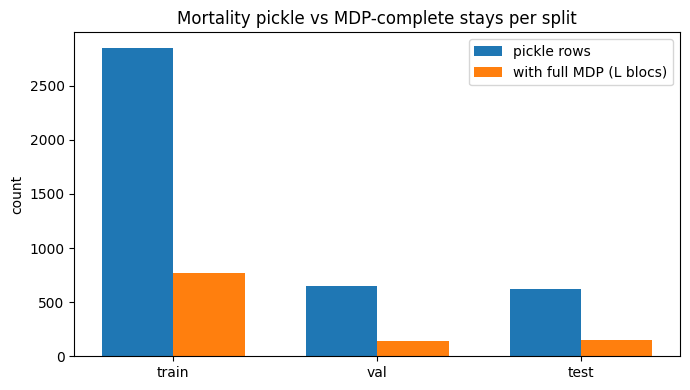

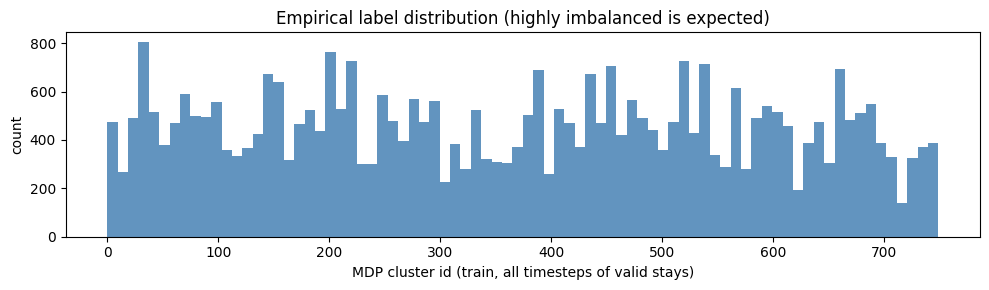

In [3]:
from utils.embedding_data_utils import load_icustay_ids_split, load_xy_split


def split_mdp_alignment(split: str) -> dict:
    X_np, _y_mort = load_xy_split(MORTALITY_PICKLE, split)
    icu = load_icustay_ids_split(MORTALITY_PICKLE, split)
    if X_np.shape[0] != len(icu):
        raise RuntimeError("Pickle X rows != icustay_id length")
    states_mat, valid = per_bloc_state_matrix(
        df_states,
        icu,
        n_blocs=N_BLOCS,
        max_state_exclusive=int(n_cluster),
    )
    n_ok = int(valid.sum())
    n_tot = len(icu)
    return {
        "split": split,
        "pickle_rows": n_tot,
        "full_mdp_trajectory_stays": n_ok,
        "fraction_kept": n_ok / max(n_tot, 1),
        "missing_mdp": n_tot - n_ok,
    }


align_rows = [split_mdp_alignment(sp) for sp in ("train", "val", "test")]
align_df = pd.DataFrame(align_rows)
display(align_df)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(align_df))
w = 0.35
ax.bar(x - w / 2, align_df["pickle_rows"], width=w, label="pickle rows")
ax.bar(x + w / 2, align_df["full_mdp_trajectory_stays"], width=w, label="with full MDP (L blocs)")
ax.set_xticks(x)
ax.set_xticklabels(list(align_df["split"]))
ax.set_ylabel("count")
ax.legend()
ax.set_title("Mortality pickle vs MDP-complete stays per split")
plt.tight_layout()
plt.show()

# label histogram (train) — how often each state appears at step level
X_tr, _ = load_xy_split(MORTALITY_PICKLE, "train")
icu_tr = load_icustay_ids_split(MORTALITY_PICKLE, "train")
sm_tr, v_tr = per_bloc_state_matrix(df_states, icu_tr, n_blocs=N_BLOCS, max_state_exclusive=int(n_cluster))
flat = sm_tr[v_tr].reshape(-1)
fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.hist(flat, bins=min(80, int(n_cluster)), color="steelblue", edgecolor="none", alpha=0.85)
ax2.set_xlabel("MDP cluster id (train, all timesteps of valid stays)")
ax2.set_ylabel("count")
ax2.set_title("Empirical label distribution (highly imbalanced is expected)")
plt.tight_layout()
plt.show()

## COPER backbone + per-step MDP head

`COPERMDPSequence` mirrors `COPER.forward` up to `LayerNorm`, then applies `mdp_head` on **all** `(B, L, D)` latents.

Sinusoidal **positional encoding** on the input sequence (before cross-attention) is controlled by `USE_POS_ENCODING` in the setup cell (`False` = no additive PE).


In [4]:
class COPERMDPSequence(COPER):
    """COPER backbone + shared linear readout on every latent slot (logits B,L,S). Mortality head unused."""

    def __init__(
        self,
        config,
        n_labels,
        input_dim,
        num_latents,
        latent_dim,
        rec_layers,
        units,
        nonlinear,
        cont_in,
        cont_out,
        emb_dim=None,
        device=torch.device("cpu"),
        *,
        n_mdp_states: int,
    ):
        super().__init__(
            config,
            n_labels,
            input_dim,
            num_latents,
            latent_dim,
            rec_layers,
            units,
            nonlinear,
            cont_in,
            cont_out,
            emb_dim=emb_dim,
            device=device,
        )
        d = int(self.norm.normalized_shape[0])
        self.mdp_head = nn.Linear(d, int(n_mdp_states))

    def forward(self, data, time_steps, obj_t, pred_t):
        setting = self.config.setting
        time_steps = time_steps[0]
        pred_t = pred_t[0]
        h = data
        if len(time_steps) == len(pred_t):
            pred_t = []
        if self.emb_dim is not None:
            h = self.embed(h)
        if self.cont_in:
            h = self.ode_in(h, time_steps, pred_t, setting)
        h = self.net(h)
        if self.second_node:
            Ln = h.shape[1]
            ts = torch.linspace(0.0, 1.0, Ln, device=h.device, dtype=h.dtype)
            h = self.ode_out(h, ts, [], setting)
        h = self.norm(h)
        return self.mdp_head(h)


def _load_raw_state_dict(pt_path: Path) -> dict:
    raw = torch.load(pt_path, map_location="cpu")
    if isinstance(raw, dict) and "model_state_dict" in raw:
        return raw["model_state_dict"]
    if isinstance(raw, dict) and "state_dict" in raw:
        return raw["state_dict"]
    return raw


def build_coper_mdp_from_template(template_stem: str, n_mdp_states: int, device: torch.device) -> COPERMDPSequence:
    json_path = MODELS_DIR / f"{template_stem}.json"
    pt_path = MODELS_DIR / f"{template_stem}.pt"
    if not json_path.is_file():
        raise FileNotFoundError(f"Missing template meta {json_path} (export from mimic-compare or adjust TEMPLATE_META_STEM).")
    meta = load_meta_json(json_path)
    h = meta["hyperparams"]
    args = _namespace_from_hyperparams(h)
    args.use_pos_encoding = USE_POS_ENCODING
    if pt_path.is_file():
        sd = _load_raw_state_dict(pt_path)
        if any(str(k).startswith("ode_out.") for k in sd.keys()):
            args.second_node = True
    return COPERMDPSequence(
        args,
        1,
        h.get("input_size_mimic", 76),
        args.num_latents,
        args.latent_dim,
        args.rec_layers,
        args.units,
        nn.Tanh,
        args.cont_in,
        args.cont_out,
        emb_dim=args.emb_dim,
        device=device,
        n_mdp_states=int(n_mdp_states),
    ).to(device)


# Architecture template (hyperparams + optional ode_out detection from matching .pt)
TEMPLATE_META_STEM = "coper_2node_drop0.5_s1_e3"
N_STATES = int(n_cluster)
model = build_coper_mdp_from_template(TEMPLATE_META_STEM, N_STATES, DEVICE)

if PRETRAINED_STEM:
    _pt = MODELS_DIR / f"{PRETRAINED_STEM}.pt"
    if not _pt.is_file():
        raise FileNotFoundError(_pt)
    _sd = _load_raw_state_dict(_pt)
    _m, _u = model.load_state_dict(_sd, strict=False)
    print("Warm-start load strict=False; typical skips: classifier.*, mdp_head.*")
    print("missing keys (sample):", sorted(_m)[:12], "..." if len(_m) > 12 else "")
else:
    print("Training mdp_head + backbone from scratch (random init).")

n_params = sum(p.numel() for p in model.parameters())
print("COPERMDPSequence | n_states", N_STATES, "| total params", n_params)


Warm-start load strict=False; typical skips: classifier.*, mdp_head.*
missing keys (sample): ['mdp_head.bias', 'mdp_head.weight'] 
COPERMDPSequence | n_states 750 | total params 336559


## Tensor packs + DataLoaders

Only stays with a full `L`-bloc MDP path are kept. Each batch: `X` `(B, T, F)`, `Y` `(B, L)` long.


In [5]:
def build_mdp_tensors(split: str) -> dict:
    X_np, _ym = load_xy_split(MORTALITY_PICKLE, split)
    icu = load_icustay_ids_split(MORTALITY_PICKLE, split)
    states_mat, valid = per_bloc_state_matrix(
        df_states,
        icu,
        n_blocs=N_BLOCS,
        max_state_exclusive=int(n_cluster),
    )
    X_np = np.asarray(X_np, dtype=np.float32)
    X_ok = X_np[valid]
    Y_ok = states_mat[valid]
    icu_ok = icu[valid]
    return {
        "X": torch.from_numpy(X_ok).float(),
        "Y": torch.from_numpy(Y_ok.astype(np.int64)).long(),
        "icustay_id": icu_ok,
        "n": int(X_ok.shape[0]),
    }


packs = {sp: build_mdp_tensors(sp) for sp in ("train", "val", "test")}
L = int(packs["train"]["Y"].shape[1])
assert L == N_BLOCS, (L, N_BLOCS)
uniform_baseline = 1.0 / float(N_STATES)
print("Train/val/test stays:", packs["train"]["n"], packs["val"]["n"], packs["test"]["n"])
print("L, N_STATES, uniform acc baseline:", L, N_STATES, uniform_baseline)


class _StayDS(Dataset):
    def __init__(self, X: torch.Tensor, Y: torch.Tensor):
        self.X, self.Y = X, Y
        self.tp = torch.linspace(0, 1, X.shape[1])

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.Y[i]


def _collate_stays(batch: list) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Stack X,Y but keep a single 1D time grid (COPER ODE expects scalar time diffs, not (B,T))."""
    X = torch.stack([b[0] for b in batch], dim=0)
    Y = torch.stack([b[1] for b in batch], dim=0)
    T = X.shape[1]
    tp = torch.linspace(0, 1, T, dtype=X.dtype, device=X.device)
    return X, Y, tp


def make_loader(pack: dict, shuffle: bool) -> DataLoader:
    ds = _StayDS(pack["X"], pack["Y"])
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=_collate_stays,
    )


train_loader = make_loader(packs["train"], shuffle=True)
val_loader = make_loader(packs["val"], shuffle=False)
test_loader = make_loader(packs["test"], shuffle=False)

Train/val/test stays: 768 144 151
L, N_STATES, uniform acc baseline: 48 750 0.0013333333333333333


## Training loop

Cross-entropy over all `(batch, t)` positions. Early stopping on validation CE. Plots: train/val loss and **per-step accuracy** (pooled over batches each epoch).


epoch 001 train_loss=6.7670 val_loss=6.7495 train_acc=0.00141 val_acc=0.00246
epoch 002 train_loss=6.6721 val_loss=6.6941 train_acc=0.00250 val_acc=0.00260
epoch 003 train_loss=6.5590 val_loss=6.6338 train_acc=0.00274 val_acc=0.00174
epoch 004 train_loss=6.4613 val_loss=6.6007 train_acc=0.00467 val_acc=0.00159
epoch 005 train_loss=6.3949 val_loss=6.5853 train_acc=0.00450 val_acc=0.00087
epoch 006 train_loss=6.3511 val_loss=6.5788 train_acc=0.00477 val_acc=0.00101
epoch 007 train_loss=6.3197 val_loss=6.5832 train_acc=0.00602 val_acc=0.00304
epoch 008 train_loss=6.2980 val_loss=6.5838 train_acc=0.00673 val_acc=0.00376
epoch 009 train_loss=6.2813 val_loss=6.5885 train_acc=0.00705 val_acc=0.00376
epoch 010 train_loss=6.2658 val_loss=6.5899 train_acc=0.00722 val_acc=0.00391
epoch 011 train_loss=6.2449 val_loss=6.5851 train_acc=0.00817 val_acc=0.00477
epoch 012 train_loss=6.2216 val_loss=6.5769 train_acc=0.00906 val_acc=0.00420
epoch 013 train_loss=6.1974 val_loss=6.5685 train_acc=0.01115 va

,epoch,train_loss,val_loss,train_acc,val_acc
24,25,5.903349,6.519551,0.020345,0.003617
25,26,5.880846,6.513198,0.022163,0.003906
26,27,5.862164,6.509600,0.023926,0.003762
27,28,5.838120,6.507353,0.026069,0.004051
28,29,5.816294,6.507914,0.026476,0.003906
29,30,5.795695,6.504237,0.027751,0.003617


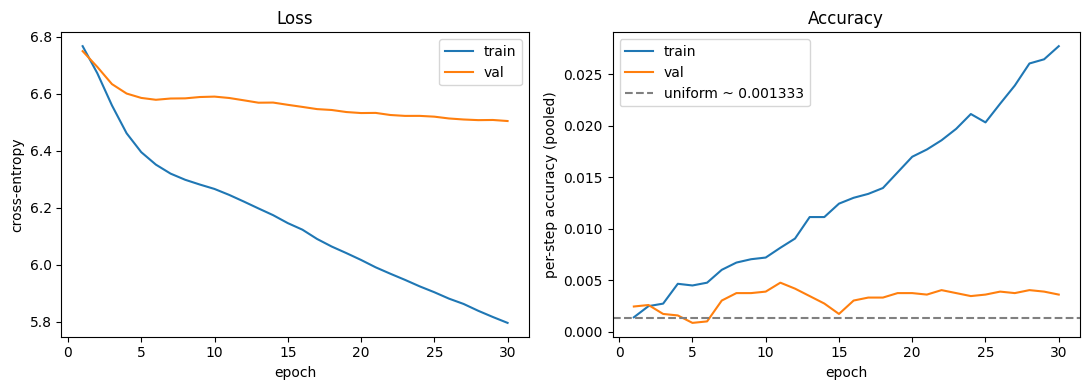

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/train_coper_to_mdp/models/coper_mdp_sequence.pt


In [6]:
opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def run_epoch(loader: DataLoader, train: bool) -> tuple[float, float]:
    if train:
        model.train()
    else:
        model.eval()
    tot_loss = 0.0
    tot_ok = tot_n = 0
    nb = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb, Yb, tp in loader:
            Xb = Xb.to(DEVICE)
            Yb = Yb.to(DEVICE)
            tp = tp.to(DEVICE)
            logits = model(Xb, [tp], [tp], [tp])
            loss = F.cross_entropy(logits.reshape(-1, N_STATES), Yb.reshape(-1))
            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()
            tot_loss += float(loss.item())
            pred = logits.argmax(dim=-1)
            tot_ok += int((pred == Yb).sum().item())
            tot_n += int(Yb.numel())
            nb += 1
    return tot_loss / max(nb, 1), tot_ok / max(tot_n, 1)


history = []
best_val = float("inf")
best_state = None
bad = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_l, tr_a = run_epoch(train_loader, True)
    va_l, va_a = run_epoch(val_loader, False)
    history.append(
        {"epoch": epoch, "train_loss": tr_l, "val_loss": va_l, "train_acc": tr_a, "val_acc": va_a}
    )
    print(f"epoch {epoch:03d} train_loss={tr_l:.4f} val_loss={va_l:.4f} train_acc={tr_a:.5f} val_acc={va_a:.5f}")
    if va_l < best_val - 1e-5:
        best_val = va_l
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
    if bad >= PATIENCE:
        print(f"Early stop at epoch {epoch} (patience={PATIENCE})")
        break

if best_state is not None:
    model.load_state_dict(best_state)

hist_df = pd.DataFrame(history)
display(hist_df.tail(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")
axes[0].legend()
axes[0].set_title("Loss")
axes[1].plot(hist_df["epoch"], hist_df["train_acc"], label="train")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"], label="val")
axes[1].axhline(uniform_baseline, color="gray", linestyle="--", label=f"uniform ~ {uniform_baseline:.4g}")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("per-step accuracy (pooled)")
axes[1].legend()
axes[1].set_title("Accuracy")
plt.tight_layout()
plt.savefig(FIG_DIR / "train_curves.png", dpi=150)
plt.show()

ckpt_path = MODEL_DIR / "coper_mdp_sequence.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "hyperparams_template": TEMPLATE_META_STEM,
        "pretrained_stem": PRETRAINED_STEM,
        "use_pos_encoding": USE_POS_ENCODING,
        "n_states": N_STATES,
        "n_blocs": N_BLOCS,
        "slug": SLUG,
        "history": history,
        "best_val_loss": best_val,
    },
    ckpt_path,
)
print("Saved", ckpt_path)

## Test metrics + trajectory plots (same style as `copers_to_states`)

Per-stay step accuracy, histogram on test, and worst / median / best stays: GT vs argmax predictions.


Test pooled per-step accuracy: 0.004552979953587055 | uniform baseline: 0.0013333333333333333
Mean per-stay acc (test): 0.004552979953587055 | median: 0.0


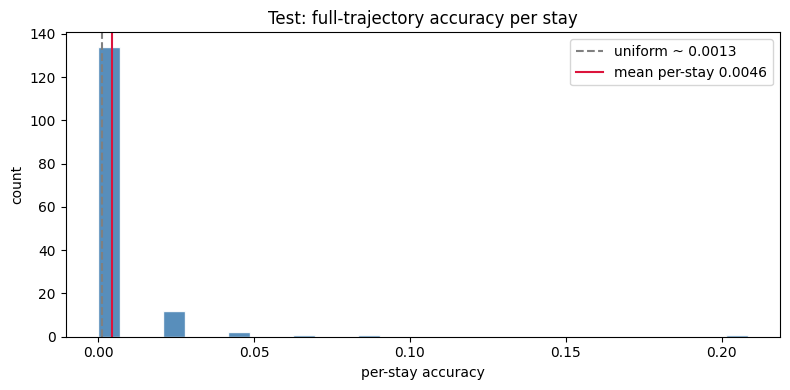

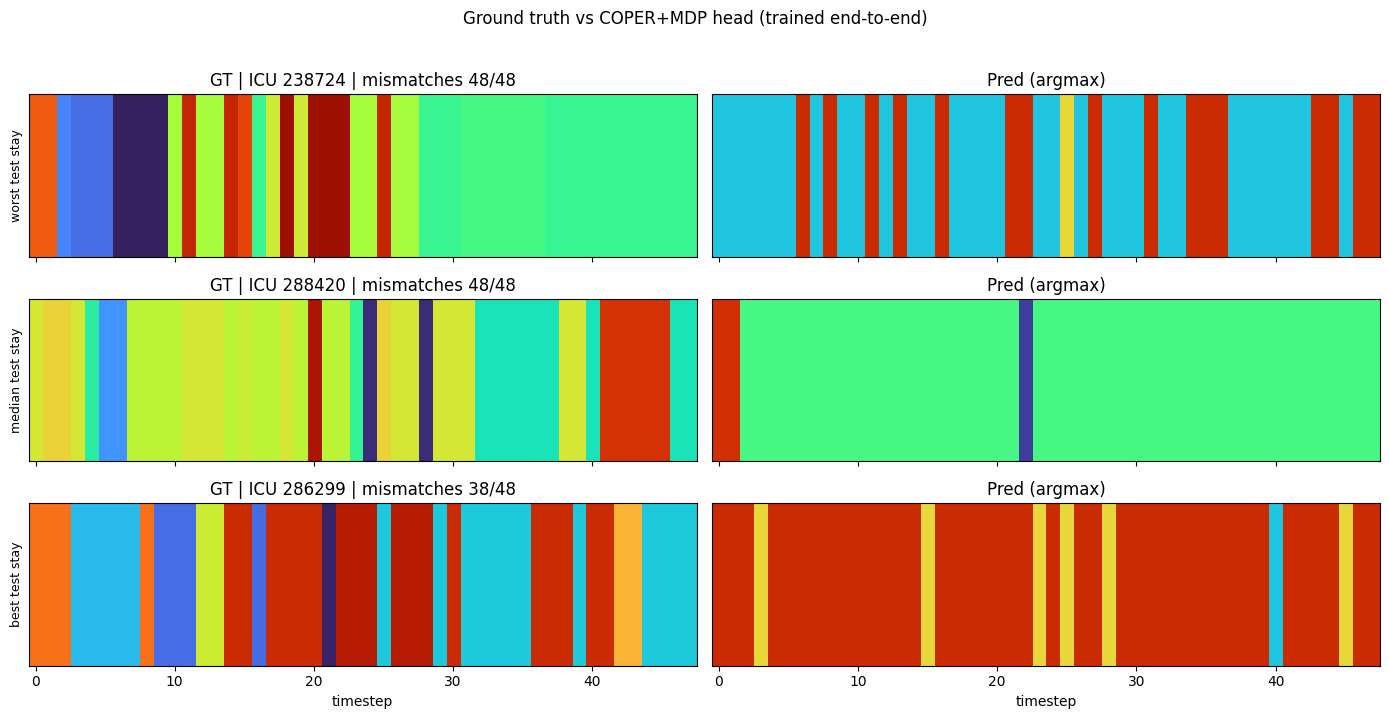

Wrote /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/train_coper_to_mdp/models/train_coper_to_mdp_summary.json


In [7]:
@torch.no_grad()
def forward_all(model: nn.Module, pack: dict, batch_size: int = 32) -> tuple[torch.Tensor, np.ndarray]:
    model.eval()
    loader = make_loader(pack, shuffle=False)
    preds = []
    fracs = []
    for Xb, Yb, tp in loader:
        Xb = Xb.to(DEVICE)
        Yb = Yb.to(DEVICE)
        tp = tp.to(DEVICE)
        logits = model(Xb, [tp], [tp], [tp])
        pred = logits.argmax(dim=-1).cpu()
        preds.append(pred)
        fracs.append((pred == Yb.cpu()).float().mean(dim=1).numpy())
    pred = torch.cat(preds, dim=0)
    acc_i = np.concatenate(fracs, axis=0)
    return pred, acc_i


pred_te, acc_te = forward_all(model, packs["test"])
Y_te = packs["test"]["Y"]
icu_te = packs["test"]["icustay_id"]
_, acc_tr = forward_all(model, packs["train"])
_, acc_va = forward_all(model, packs["val"])

pool_te = float((pred_te == Y_te).float().mean())
print("Test pooled per-step accuracy:", pool_te, "| uniform baseline:", uniform_baseline)
print("Mean per-stay acc (test):", float(acc_te.mean()), "| median:", float(np.median(acc_te)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(acc_te, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(uniform_baseline, color="gray", linestyle="--", label=f"uniform ~ {uniform_baseline:.4f}")
ax.axvline(float(acc_te.mean()), color="crimson", linestyle="-", label=f"mean per-stay {acc_te.mean():.4f}")
ax.set_xlabel("per-stay accuracy")
ax.set_ylabel("count")
ax.set_title("Test: full-trajectory accuracy per stay")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "test_per_stay_hist.png", dpi=150)
plt.show()

order = np.argsort(acc_te)
idx_w, idx_m, idx_b = int(order[0]), int(order[len(order) // 2]), int(order[-1])
vmax = max(N_STATES - 1, 1)

fig, axes = plt.subplots(3, 2, figsize=(14, 7), sharex=True)
for row, (idx, title) in enumerate(
    ((idx_w, "worst test stay"), (idx_m, "median test stay"), (idx_b, "best test stay"))
):
    gt = Y_te[idx].numpy()
    pr = pred_te[idx].numpy()
    mm = int((gt != pr).sum())
    axes[row, 0].imshow(gt.reshape(1, -1), aspect="auto", cmap="turbo", vmin=0, vmax=vmax, interpolation="nearest")
    axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(title, rotation=90, size=9)
    axes[row, 0].set_title(f"GT | ICU {int(icu_te[idx])} | mismatches {mm}/{L}")
    axes[row, 1].imshow(pr.reshape(1, -1), aspect="auto", cmap="turbo", vmin=0, vmax=vmax, interpolation="nearest")
    axes[row, 1].set_yticks([])
    axes[row, 1].set_title("Pred (argmax)")
axes[-1, 0].set_xlabel("timestep")
axes[-1, 1].set_xlabel("timestep")
plt.suptitle("Ground truth vs COPER+MDP head (trained end-to-end)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "trajectory_examples.png", dpi=150)
plt.show()

summary_path = MODEL_DIR / "train_coper_to_mdp_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "test_pooled_per_step_acc": pool_te,
            "test_mean_per_stay_acc": float(acc_te.mean()),
            "train_mean_per_stay_acc": float(acc_tr.mean()),
            "val_mean_per_stay_acc": float(acc_va.mean()),
            "n_states": N_STATES,
            "stays": {k: packs[k]["n"] for k in packs},
        },
        f,
        indent=2,
    )
print("Wrote", summary_path)

## Trajectoires en courbes (mêmes séjours test)

Les heatmaps ci-dessus montrent la même information en **lignes** : abscisse = pas de temps (`0 … L-1`), ordonnée = **indice d’état MDP** (cluster). Courbes **GT** vs **argmax** pour les trois séjours (pire / médian / meilleur accuracy par séjour).

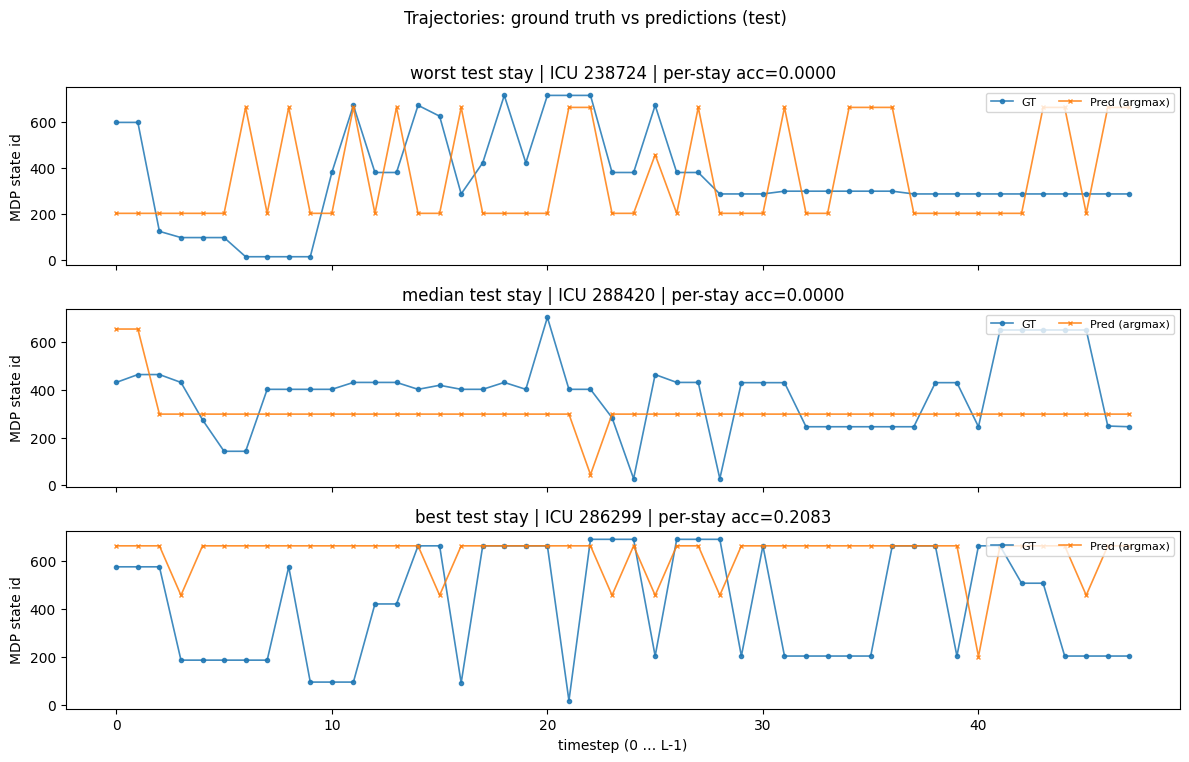

In [8]:
t = np.arange(L, dtype=np.int64)
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
for ax, idx, title in zip(
    axes,
    (idx_w, idx_m, idx_b),
    ("worst test stay", "median test stay", "best test stay"),
):
    gt = Y_te[idx].numpy()
    pr = pred_te[idx].numpy()
    ax.plot(t, gt, label="GT", marker="o", markersize=3, alpha=0.85, linewidth=1.2)
    ax.plot(t, pr, label="Pred (argmax)", marker="x", markersize=3, alpha=0.85, linewidth=1.2)
    ax.set_ylabel("MDP state id")
    ax.set_title(f"{title} | ICU {int(icu_te[idx])} | per-stay acc={float(acc_te[idx]):.4f}")
    ax.legend(loc="upper right", ncol=2, fontsize=8)
axes[-1].set_xlabel("timestep (0 … L-1)")
plt.suptitle("Trajectories: ground truth vs predictions (test)", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "trajectory_line_plots.png", dpi=150)
plt.show()